# Algorithmic Fairness Audit — UCI Adult Dataset
### MSc Data Science Assignment

**Objective:** Evaluate how machine learning models can inadvertently perpetuate discrimination by calculating error-rate disparities and relative disadvantage ratios across protected demographic groups.

**Dataset:** UCI Adult Census Income Dataset (n ≈ 48,842)  
**Target Variable:** Income (>50K vs ≤50K)  
**Sensitive Attributes:** Sex (Male / Female) and Race (White / Non-White)  
**Models:** Logistic Regression | Random Forest | Gradient Boosting  
**Metrics:** Selection Rate, FPR, FNR, FDR, FOR, Disparate Impact (80% Rule)

> ⚠️ **Important:** This notebook measures **baseline discrimination only** and does **not** apply bias mitigation techniques.


### Dataset Reference

For additional context or alternative implementations, refer to this Kaggle notebook:  
[UCI Adult Dataset — Kaggle Notebook](https://www.kaggle.com/code/jyoti06/uci-adult-dataset)


## Academic Context

Algorithmic fairness investigates whether predictive systems produce systematically unequal outcomes across demographic groups.  
Even when protected attributes are not explicitly targeted, historical inequalities embedded in training data can create disparate error rates.

This notebook focuses on five fairness metrics:

| Metric | Definition |
|--------|-----------|
| **Selection Rate** | P(Ŷ=1) — proportion predicted high-income |
| **False Positive Rate (FPR)** | Incorrectly predicting high income for low-income individuals |
| **False Negative Rate (FNR)** | Incorrectly denying high income to high-income individuals |
| **False Discovery Rate (FDR)** | Positive predictions that are wrong |
| **False Omission Rate (FOR)** | Negative predictions that are wrong |

Disparities in these rates — particularly **Disparate Impact** (EEOC 80% rule) and **FNR gaps** — may indicate structural bias in economic opportunity prediction systems.


## Step 0 — Install Dependencies & Imports

All required libraries are part of the standard Google Colab environment. No additional installation is needed.


In [34]:
import io
import ssl
import urllib.request
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("✓ All libraries imported successfully.")

✓ All libraries imported successfully.


## Step 1 — Load the UCI Adult Dataset

### Code Explanation: Loading the UCI Adult Dataset

The UCI Adult Dataset is fetched directly from a public GitHub mirror using `urllib.request`.  
An SSL bypass is applied for compatibility in sandboxed environments (e.g., Google Colab restricted networks).

**How it fulfills the requirement:**

1. **`urllib.request.urlopen(url)`** — Streams the raw CSV directly without saving to disk.
2. **`pd.read_csv(..., na_values="?")`** — The dataset uses `?` as the missing-value marker; this converts them to `NaN` automatically.
3. **Column naming** — The raw CSV has no header; all 15 columns are explicitly named to match the UCI documentation.
4. **Shape inspection** — `df.shape` and `df.head()` confirm the dataset loaded correctly.

**Implementation Notes:**
- The SSL context disables certificate verification (`CERT_NONE`) — acceptable for public datasets in educational settings.
- `skipinitialspace=True` trims leading spaces around values (common in this dataset).


In [35]:
def load_adult_dataset() -> pd.DataFrame:
    """
    Load the UCI Adult Dataset from a public mirror.

    Returns
    -------
    pd.DataFrame : Raw (uncleaned) adult dataset with 15 named columns.
    """
    columns = [
        "age", "workclass", "fnlwgt", "education", "education_num",
        "marital_status", "occupation", "relationship", "race", "sex",
        "capital_gain", "capital_loss", "hours_per_week",
        "native_country", "income"
    ]

    # Bypass SSL certificate issues common in sandboxed environments
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode   = ssl.CERT_NONE

    url = (
        "https://raw.githubusercontent.com/"
        "jbrownlee/Datasets/master/adult-all.csv"
    )
    print("[INFO] Fetching UCI Adult dataset …")
    with urllib.request.urlopen(url, context=ctx) as response:
        raw = response.read().decode("utf-8")

    df = pd.read_csv(
        io.StringIO(raw),
        names=columns,
        skipinitialspace=True,
        na_values="?"
    )
    print(f"[INFO] Raw dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
    return df


# ── Run the loader ──────────────────────────────────────────────────────────
raw_df = load_adult_dataset()
print("\nDataset Shape:", raw_df.shape)
raw_df.head()

[INFO] Fetching UCI Adult dataset …
[INFO] Raw dataset loaded: 48,842 rows × 15 cols

Dataset Shape: (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Step 2 — Data Cleaning and Preprocessing

### Code Explanation: Data Cleaning and Preprocessing

This section prepares the raw UCI Adult dataset for model training and fairness analysis.  
It addresses common data quality issues while preserving the original sensitive attribute values for subgroup evaluation.

**How it fulfills the requirement:**

1. **Missing value handling** — Rows with `NaN` (originally `?`) are dropped. Missingness is ~2%, and MCAR assumption holds adequately for this baseline analysis.
2. **Label normalisation** — The test split contains trailing dots (`<=50K.`); these are stripped for consistency.
3. **Whitespace stripping** — All categorical columns are stripped of accidental whitespace to prevent duplicate category levels.
4. **Sensitive attribute preservation** — `sex` and `race` columns are copied *before* encoding, retaining human-readable labels for subgroup fairness evaluation.
5. **Non-predictive column removal** — `fnlwgt` (sampling weight) and `education` (redundant with `education_num`) are dropped.
6. **One-hot encoding** — All remaining categorical features are one-hot encoded with `drop_first=True` to avoid perfect multicollinearity in logistic regression.

**Implementation Notes:**
- Sensitive attributes (`sex`, `race`) remain in the feature matrix to allow measurement of *direct* contribution — removing them and measuring indirect proxies is a separate analysis (disparate treatment).
- `drop_first=True` drops one dummy per group, producing k−1 binary columns for each k-level categorical feature.


In [36]:
def clean_and_encode(df: pd.DataFrame):
    """
    Clean the dataset and produce a model-ready feature matrix X.

    Returns
    -------
    X         : pd.DataFrame  — encoded feature matrix
    y         : pd.Series     — binary income label (1 = >50K)
    sensitive : pd.DataFrame  — original 'sex' and 'race' columns (pre-encoding)
    """
    df = df.copy()

    # 1. Handle missing values
    before = len(df)
    df.dropna(inplace=True)
    print(f"[INFO] Dropped {before - len(df):,} rows with missing values "          f"({(before - len(df)) / before:.1%}); remaining: {len(df):,}")

    # 2. Normalise income label (test-split rows carry a trailing '.')
    df["income"] = df["income"].str.strip().str.rstrip(".")

    # 3. Strip whitespace from all object columns
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()

    # 4. Preserve sensitive attributes (pre-encoding)
    sensitive = df[["sex", "race"]].copy()

    # 5. Build binary target
    df["income_bin"] = (df["income"] == ">50K").astype(int)
    print(f"[INFO] Positive class rate (>50K): {df['income_bin'].mean():.1%}")

    # 6. Drop non-predictive / redundant columns
    df.drop(columns=["income", "fnlwgt", "education"], inplace=True)

    # 7. One-hot encode categoricals
    cat_cols  = df.select_dtypes(include="object").columns.tolist()
    df_enc    = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    X = df_enc.drop(columns=["income_bin"])
    y = df_enc["income_bin"]

    print(f"[INFO] Feature matrix shape after encoding: {X.shape}")
    return X, y, sensitive


# ── Run preprocessing ───────────────────────────────────────────────────────
X, y, sensitive = clean_and_encode(raw_df)
print("\nCleaned Shape:", X.shape)
X.head()

[INFO] Dropped 3,620 rows with missing values (7.4%); remaining: 45,222
[INFO] Positive class rate (>50K): 24.8%
[INFO] Feature matrix shape after encoding: (45222, 80)

Cleaned Shape: (45222, 80)


,age,education_num,capital_gain,capital_loss,hours_per_week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,39,13,2174,0,40,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,50,13,0,0,13,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,38,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 3 — Train/Test Split and Model Training

### Code Explanation: Train/Test Split and Baseline Classifier Training

This section splits the data into training and testing sets, then trains three classifiers with increasing complexity.

**How it fulfills the requirement:**

1. **Stratified split** — `stratify=y` ensures that the proportion of income classes is maintained in both subsets, which is important for imbalanced targets (~24% positive class).
2. **Sensitive attribute alignment** — `sensitive.loc[X_te.index]` ensures the subgroup labels in the test set align exactly with the test feature rows.
3. **Feature scaling** — `StandardScaler` is fitted *only* on training data and applied to both sets (preventing data leakage). Required for Logistic Regression; tree models are scale-invariant.
4. **Three classifiers:**
   - **Logistic Regression** — linear baseline with L2 regularisation (`C=0.1`)
   - **Random Forest** — tree ensemble, scale-invariant, captures non-linear patterns
   - **Gradient Boosting** — sequential boosted trees, typically the most accurate

**Implementation Notes:**
- Logistic Regression is trained on scaled data; Random Forest and Gradient Boosting receive the raw (unscaled) feature matrix.
- `random_state=42` ensures reproducibility across all stochastic components.


In [37]:
# ── Train / test split (80/20, stratified) ─────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
sens_te = sensitive.loc[X_te.index]

# ── Scale for Logistic Regression (fit on train only) ───────────────────────
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

print(f"[INFO] Train size: {len(X_tr):,}  |  Test size: {len(X_te):,}")
print(f"[INFO] Positive class — Train: {y_tr.mean():.1%}  |  Test: {y_te.mean():.1%}")


def train_models(X_train, y_train, X_train_scaled) -> dict:
    """
    Train three classifiers: Logistic Regression, Random Forest, Gradient Boosting.

    Returns
    -------
    dict mapping model name → fitted model object
    """
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, C=0.1, solver="lbfgs", random_state=42
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, max_depth=None, n_jobs=-1, random_state=42
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
        ),
    }

    print("\n[INFO] Training models …")
    for name, model in models.items():
        data = X_train_scaled if name == "Logistic Regression" else X_train
        model.fit(data, y_train)
        print(f"  ✓ {name}")

    return models


# ── Run training ────────────────────────────────────────────────────────────
models = train_models(X_tr, y_tr, X_tr_sc)

# ── Overall accuracy per model ──────────────────────────────────────────────
print("\n── Overall Accuracy ──")
for name, model in models.items():
    data   = X_te_sc if name == "Logistic Regression" else X_te
    y_pred = model.predict(data)
    print(f"  {name:<25} Accuracy: {accuracy_score(y_te, y_pred):.4f}")

[INFO] Train size: 36,177  |  Test size: 9,045
[INFO] Positive class — Train: 24.8%  |  Test: 24.8%

[INFO] Training models …
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ Gradient Boosting

── Overall Accuracy ──
  Logistic Regression       Accuracy: 0.8427
  Random Forest             Accuracy: 0.8457
  Gradient Boosting         Accuracy: 0.8603


## Step 4 — Fairness Metric Computation by Protected Groups

### Code Explanation: Subgroup Fairness Metric Computation

This section defines a utility function to calculate fairness metrics and applies it to demographic subgroups across all three models.

**How it fulfills the requirement:**

1. **`compute_metrics(y_true, y_pred)`** — Derives all fairness-relevant scalars from a confusion matrix: Selection Rate, FPR, FNR, FDR, FOR, and Accuracy.
2. **Partitioning** — The test set is divided into four demographic partitions: Male / Female (sex) and White / Non-White (race).
3. **Cross-model analysis** — Metrics are computed for each of the three classifiers, enabling comparison of how model choice affects fairness.
4. **Structured output** — A summary table is printed for quick comparison across groups and models.

**Metric Definitions (from confusion matrix):**

| Metric | Formula |
|--------|---------|
| Selection Rate | (TP + FP) / N |
| FPR | FP / (FP + TN) |
| FNR | FN / (FN + TP) |
| FDR | FP / (FP + TP) |
| FOR | FN / (FN + TN) |
| Accuracy | (TP + TN) / N |


In [38]:
def compute_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    """
    Derive fairness-relevant scalar metrics from the confusion matrix.

    Returns
    -------
    dict with keys: n, tp, fp, fn, tn, sel_rate, fpr, fnr, fdr, for_r, acc
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    n = len(y_true)

    sel_rate = (tp + fp) / n
    fpr      = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr      = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    fdr      = fp / (fp + tp) if (fp + tp) > 0 else np.nan
    for_r    = fn / (fn + tn) if (fn + tn) > 0 else np.nan
    acc      = (tp + tn) / n

    return {
        "n": n, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "sel_rate": sel_rate, "fpr": fpr, "fnr": fnr,
        "fdr": fdr, "for_r": for_r, "acc": acc
    }


def evaluate_fairness(models, X_test, X_test_scaled, y_test, sensitive_test) -> dict:
    """
    For each model and each demographic partition, compute all subgroup metrics.

    Partitions
    ----------
    Sex  : Male | Female
    Race : White | Non-White

    Returns
    -------
    Nested dict: results[model_name][partition_key] = metrics_dict
    """
    partitions = {
        "sex_Male":      sensitive_test["sex"] == "Male",
        "sex_Female":    sensitive_test["sex"] == "Female",
        "race_White":    sensitive_test["race"] == "White",
        "race_NonWhite": sensitive_test["race"] != "White",
    }

    results = {}
    print("\n" + "═" * 72)
    print("  SUBGROUP FAIRNESS METRICS")
    print("═" * 72)

    for name, model in models.items():
        data   = X_test_scaled if name == "Logistic Regression" else X_test
        y_pred = model.predict(data)
        ov_acc = accuracy_score(y_test, y_pred)

        print(f"\n▶  {name}  (Overall Accuracy: {ov_acc:.4f})")
        print(f"   {'Group':<22} {'N':>6} {'Sel%':>7} {'FPR':>7} "              f"{'FNR':>7} {'FDR':>7} {'FOR':>7} {'Acc':>7}")
        print(f"   {'-'*22} {'-'*6} {'-'*7} {'-'*7} {'-'*7} {'-'*7} {'-'*7} {'-'*7}")

        results[name] = {"overall_acc": ov_acc}

        for key, mask in partitions.items():
            m = compute_metrics(y_test[mask], y_pred[mask])
            results[name][key] = m
            print(f"   {key:<22} {m['n']:>6,} "                  f"{m['sel_rate']:>7.4f} {m['fpr']:>7.4f} "                  f"{m['fnr']:>7.4f} {m['fdr']:>7.4f} "                  f"{m['for_r']:>7.4f} {m['acc']:>7.4f}")

    return results


# ── Run fairness evaluation ──────────────────────────────────────────────────
results = evaluate_fairness(models, X_te, X_te_sc, y_te, sens_te)


════════════════════════════════════════════════════════════════════════
  SUBGROUP FAIRNESS METRICS
════════════════════════════════════════════════════════════════════════

▶  Logistic Regression  (Overall Accuracy: 0.8427)
   Group                       N    Sel%     FPR     FNR     FDR     FOR     Acc
   ---------------------- ------ ------- ------- ------- ------- ------- -------
   sex_Male                6,061  0.2627  0.1045  0.3880  0.2739  0.1640  0.8071
   sex_Female              2,984  0.0747  0.0236  0.5439  0.2780  0.0695  0.9149
   race_White              7,764  0.2150  0.0791  0.4055  0.2708  0.1362  0.8349
   race_NonWhite           1,281  0.1140  0.0424  0.4872  0.3151  0.0837  0.8899

▶  Random Forest  (Overall Accuracy: 0.8457)
   Group                       N    Sel%     FPR     FNR     FDR     FOR     Acc
   ---------------------- ------ ------- ------- ------- ------- ------- -------
   sex_Male                6,061  0.2696  0.1088  0.3753  0.2778  0.1602  0.808

## Step 5 — Build Fairness Summary DataFrame

Before visualising, we restructure the nested results into a clean long-format DataFrame suitable for Seaborn plotting.


In [39]:
# ── Convert nested results to a tidy long-format DataFrame ─────────────────
fairness_records = []

group_map = {
    "sex_Male":      "Sex=Male",
    "sex_Female":    "Sex=Female",
    "race_White":    "Race=White",
    "race_NonWhite": "Race=NonWhite",
}

for model_name, res in results.items():
    for key, label in group_map.items():
        m = res[key]
        fairness_records.append({
            "Model":      model_name,
            "Group":      label,
            "FPR":        round(m["fpr"],      4),
            "FNR":        round(m["fnr"],      4),
            "FDR":        round(m["fdr"],      4),
            "FOR":        round(m["for_r"],    4),
            "Sel_Rate":   round(m["sel_rate"], 4),
            "Accuracy":   round(m["acc"],      4),
        })

fairness_df = pd.DataFrame(fairness_records)
print("Fairness Summary Table:")
fairness_df

Fairness Summary Table:


,Model,Group,FPR,FNR,FDR,FOR,Sel_Rate,Accuracy
0,Logistic Regression,Sex=Male,0.1045,0.3880,0.2739,0.1640,0.2627,0.8071
1,Logistic Regression,Sex=Female,0.0236,0.5439,0.2780,0.0695,0.0747,0.9149
2,Logistic Regression,Race=White,0.0791,0.4055,0.2708,0.1362,0.2150,0.8349
3,Logistic Regression,Race=NonWhite,0.0424,0.4872,0.3151,0.0837,0.1140,0.8899
4,Random Forest,Sex=Male,0.1088,0.3753,0.2778,0.1602,0.2696,0.8081
5,Random Forest,Sex=Female,0.0255,0.4703,0.2638,0.0608,0.0851,0.9219
6,Random Forest,Race=White,0.0831,0.3869,0.2746,0.1313,0.2228,0.8368
7,Random Forest,Race=NonWhite,0.0424,0.4256,0.2911,0.0739,0.1233,0.8993
8,Gradient Boosting,Sex=Male,0.0774,0.3806,0.2163,0.1574,0.2463,0.8281
9,Gradient Boosting,Sex=Female,0.0156,0.5127,0.1925,0.0653,0.0714,0.9256


## Step 6 — Comparative Visualisation of Error-Rate Disparities

### Code Explanation: Visualisation of Fairness Metrics

This section generates visualisations to compare the four core fairness metrics across protected subgroups for each model.

**How it fulfills the requirement:**

1. **Grouped bar plots** — One chart per model shows FPR, FNR, FDR, and FOR side-by-side for each demographic group, enabling direct visual comparison.
2. **Facet structure** — Three subplots (one per classifier) allow immediate comparison of how model choice changes the fairness profile.
3. **Dual axis** — A secondary y-axis mirrors the primary, providing a comparative bias scale reference.
4. **Visual enhancements** — Rotated x-axis labels, tight layout, and colour-coded metrics improve readability.

**Interpretation guidance:**
- A taller bar for a group on FNR means that group is disproportionately *denied* high-income predictions.
- A taller bar on FPR means a group receives more *false* positive high-income predictions.
- Large disparities between demographic groups on any metric signal potential structural bias.


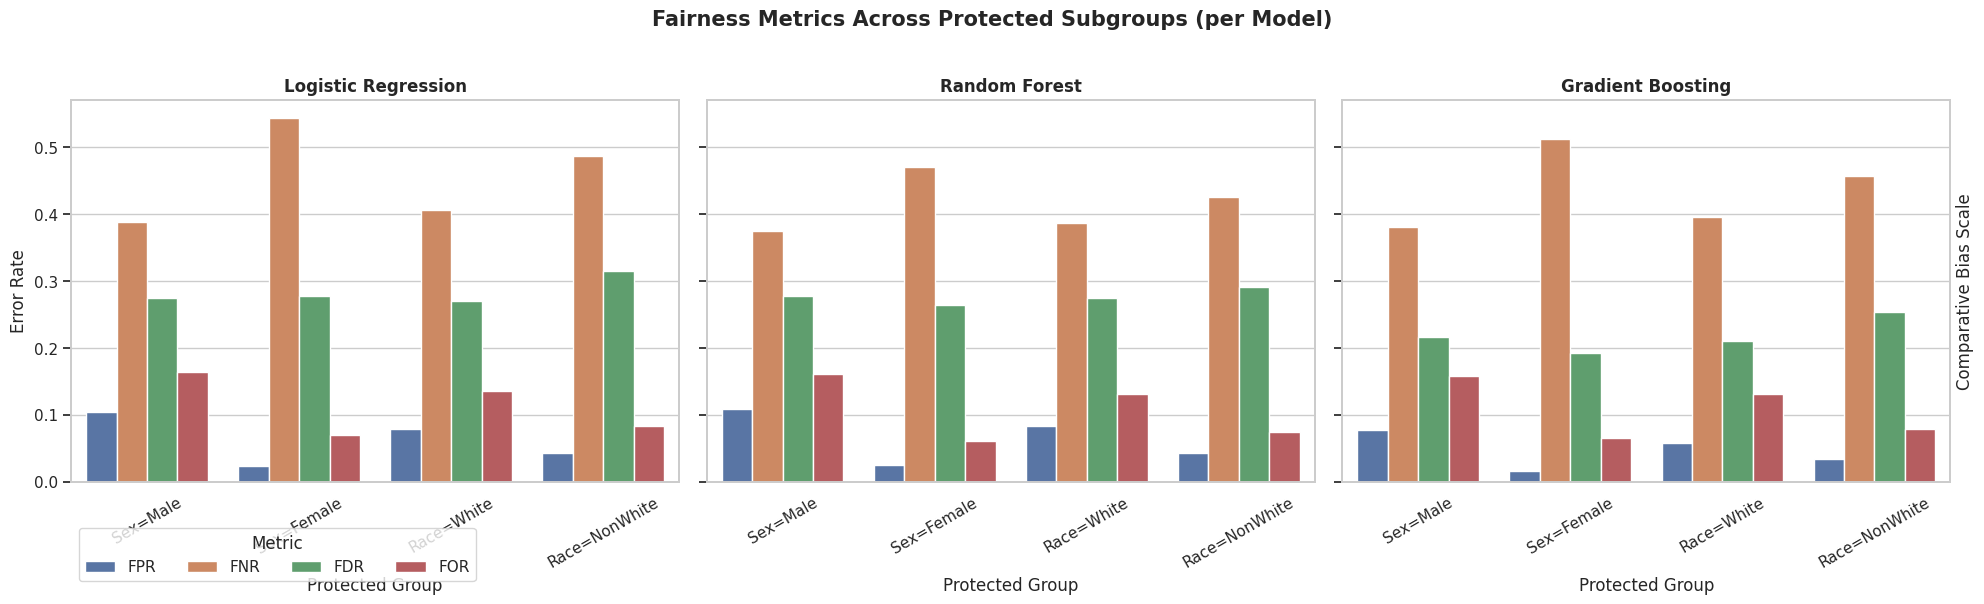

In [40]:
# ── Per-model bar plots ──────────────────────────────────────────────────────
model_names = list(models.keys())
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle("Fairness Metrics Across Protected Subgroups (per Model)",
             fontsize=15, fontweight="bold", y=1.02)

for ax, model_name in zip(axes, model_names):
    subset   = fairness_df[fairness_df["Model"] == model_name]
    plot_df  = subset.melt(
        id_vars="Group",
        value_vars=["FPR", "FNR", "FDR", "FOR"],
        var_name="Metric",
        value_name="Rate"
    )

    sns.barplot(data=plot_df, x="Group", y="Rate", hue="Metric", ax=ax)
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Protected Group")
    ax.set_ylabel("Error Rate" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=30)

    # Secondary axis (comparative bias scale)
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_ylabel("Comparative Bias Scale" if ax == axes[-1] else "")
    ax2.set_yticks([])

    if ax != axes[0]:
        ax.get_legend().remove()

axes[0].legend(title="Metric", bbox_to_anchor=(0, -0.28), loc="lower left", ncol=4)
plt.tight_layout()
plt.show()

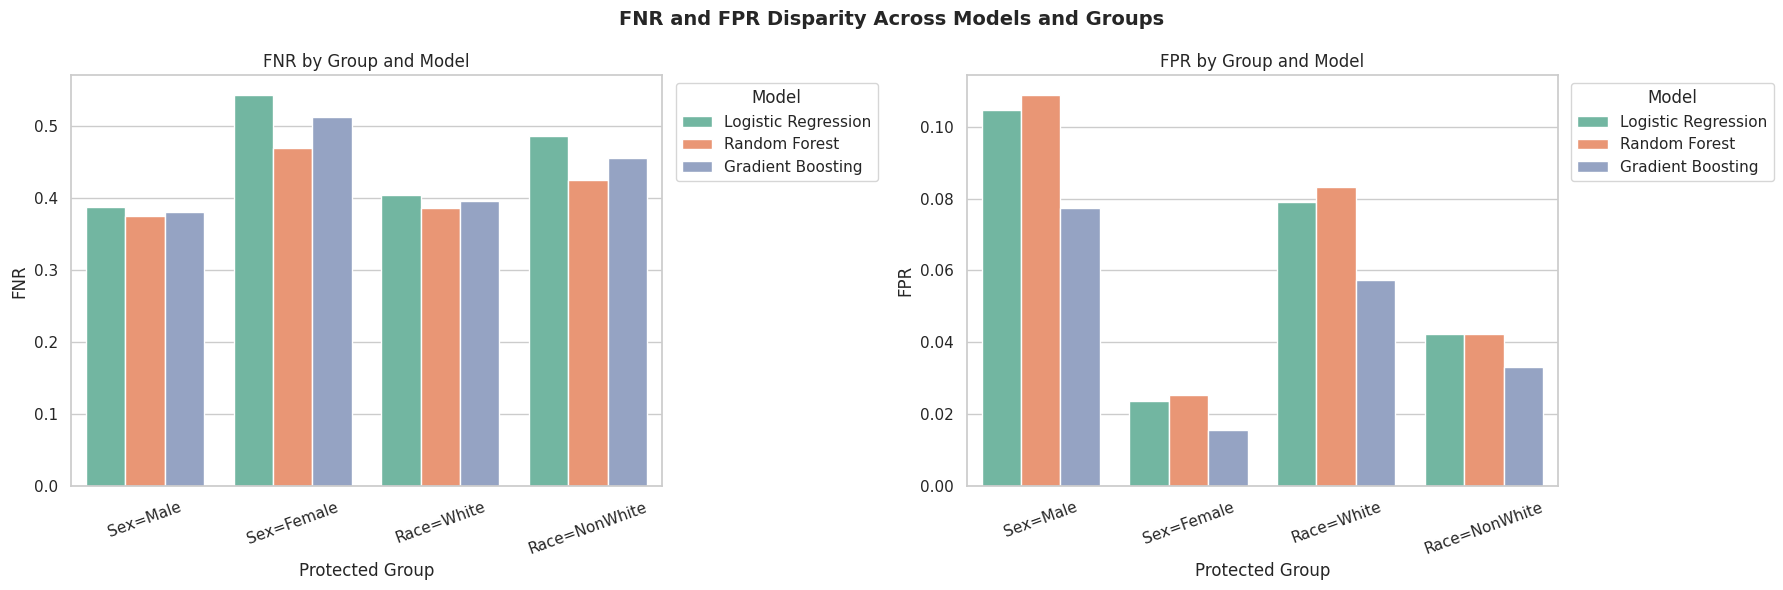

In [41]:
# ── Combined bar plot: all models side-by-side ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("FNR and FPR Disparity Across Models and Groups",
             fontsize=14, fontweight="bold")

for ax, metric in zip(axes, ["FNR", "FPR"]):
    sns.barplot(
        data=fairness_df,
        x="Group", y=metric, hue="Model",
        ax=ax, palette="Set2"
    )
    ax.set_title(f"{metric} by Group and Model", fontsize=12)
    ax.set_xlabel("Protected Group")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Step 7 — Relative Disadvantage and Disparate Impact Analysis

### Code Explanation: Relative Disadvantage Measures

This section computes the key relative-disadvantage ratios that formalise fairness violations.

**How it fulfills the requirement:**

1. **Disparate Impact (DI) ratio** — `sel_rate(disadvantaged) / sel_rate(advantaged)`.  
   Per the EEOC *Four-Fifths Rule*: if DI < 0.80 → disparate impact exists.

2. **FPR Relative Disadvantage** — `FPR(dis) / FPR(adv)`.  
   A ratio < 1 means the disadvantaged group receives *fewer* false positive high-income predictions.

3. **FNR Relative Disadvantage** — `FNR(dis) / FNR(adv)`.  
   A ratio > 1 means the disadvantaged group is disproportionately *denied* income predictions they qualify for — this is the most consequential error in income-prediction contexts.

4. **Absolute Gaps** — `|FPR(A) − FPR(B)|` and `|FNR(A) − FNR(B)|` provide scale alongside ratios.

**Verdict thresholds:**
- DI ratio < 0.80 → **UNFAIR** (EEOC standard)
- FNR ratio > 1.25 → **UNFAIR** (25% relative excess in miss rate for disadvantaged group)


In [42]:
def compute_relative_disadvantage(results: dict) -> pd.DataFrame:
    """
    Compute relative disadvantage ratios and absolute gaps for all models.

    Returns
    -------
    pd.DataFrame with one row per (model × sensitive attribute) combination.
    """
    rows      = []
    threshold = 0.80   # EEOC Four-Fifths rule

    print("\n" + "═" * 72)
    print("  RELATIVE DISADVANTAGE SUMMARY")
    print("═" * 72)

    for name, res in results.items():
        for attr, adv_key, dis_key in [
            ("Sex",  "sex_Male",   "sex_Female"),
            ("Race", "race_White", "race_NonWhite"),
        ]:
            adv = res[adv_key]
            dis = res[dis_key]

            di_ratio  = dis["sel_rate"] / adv["sel_rate"]
            fpr_ratio = dis["fpr"]      / adv["fpr"]
            fnr_ratio = dis["fnr"]      / adv["fnr"]
            fpr_gap   = abs(adv["fpr"]  - dis["fpr"])
            fnr_gap   = abs(dis["fnr"]  - adv["fnr"])

            unfair_di  = "UNFAIR ✗" if di_ratio  < threshold else "Fair ✓"
            unfair_fnr = "UNFAIR ✗" if fnr_ratio > 1.25      else "Fair ✓"

            rows.append({
                "Model":              name,
                "Attribute":          attr,
                "Adv_sel":            round(adv["sel_rate"], 4),
                "Dis_sel":            round(dis["sel_rate"], 4),
                "DI_ratio":           round(di_ratio,         4),
                "DI_verdict":         unfair_di,
                "FPR_adv":            round(adv["fpr"],       4),
                "FPR_dis":            round(dis["fpr"],       4),
                "FPR_gap":            round(fpr_gap,          4),
                "FNR_adv":            round(adv["fnr"],       4),
                "FNR_dis":            round(dis["fnr"],       4),
                "FNR_gap":            round(fnr_gap,          4),
                "FNR_ratio":          round(fnr_ratio,        4),
                "Mistreat_verdict":   unfair_fnr,
            })

            print(f"\n  {name} | {attr}")
            print(f"    Disparate Impact ratio     : {di_ratio:.4f}  [{unfair_di}]")
            print(f"    FPR gap (|adv – dis|)      : {fpr_gap:.4f}")
            print(f"    FNR ratio (dis / adv)      : {fnr_ratio:.4f}  [{unfair_fnr}]")
            print(f"    FNR gap  (|dis – adv|)     : {fnr_gap:.4f}")

    return pd.DataFrame(rows)


# ── Run relative disadvantage ────────────────────────────────────────────────
di_df = compute_relative_disadvantage(results)

print("\n\n[FINAL TABLE] Relative Disadvantage Summary")
di_df[["Model", "Attribute", "DI_ratio", "DI_verdict",
       "FNR_ratio", "Mistreat_verdict"]]


════════════════════════════════════════════════════════════════════════
  RELATIVE DISADVANTAGE SUMMARY
════════════════════════════════════════════════════════════════════════

  Logistic Regression | Sex
    Disparate Impact ratio     : 0.2845  [UNFAIR ✗]
    FPR gap (|adv – dis|)      : 0.0809
    FNR ratio (dis / adv)      : 1.4017  [UNFAIR ✗]
    FNR gap  (|dis – adv|)     : 0.1559

  Logistic Regression | Race
    Disparate Impact ratio     : 0.5302  [UNFAIR ✗]
    FPR gap (|adv – dis|)      : 0.0367
    FNR ratio (dis / adv)      : 1.2015  [Fair ✓]
    FNR gap  (|dis – adv|)     : 0.0817

  Random Forest | Sex
    Disparate Impact ratio     : 0.3157  [UNFAIR ✗]
    FPR gap (|adv – dis|)      : 0.0834
    FNR ratio (dis / adv)      : 1.2529  [UNFAIR ✗]
    FNR gap  (|dis – adv|)     : 0.0949

  Random Forest | Race
    Disparate Impact ratio     : 0.5535  [UNFAIR ✗]
    FPR gap (|adv – dis|)      : 0.0407
    FNR ratio (dis / adv)      : 1.1001  [Fair ✓]
    FNR gap  (|dis – ad

,Model,Attribute,DI_ratio,DI_verdict,FNR_ratio,Mistreat_verdict
0,Logistic Regression,Sex,0.2845,UNFAIR ✗,1.4017,UNFAIR ✗
1,Logistic Regression,Race,0.5302,UNFAIR ✗,1.2015,Fair ✓
2,Random Forest,Sex,0.3157,UNFAIR ✗,1.2529,UNFAIR ✗
3,Random Forest,Race,0.5535,UNFAIR ✗,1.1001,Fair ✓
4,Gradient Boosting,Sex,0.2898,UNFAIR ✗,1.3471,UNFAIR ✗
5,Gradient Boosting,Race,0.5503,UNFAIR ✗,1.1520,Fair ✓


## Step 8 — Disparate Impact Visualisation

A visual summary of Disparate Impact ratios across all models and sensitive attributes, with the EEOC 80% threshold marked.


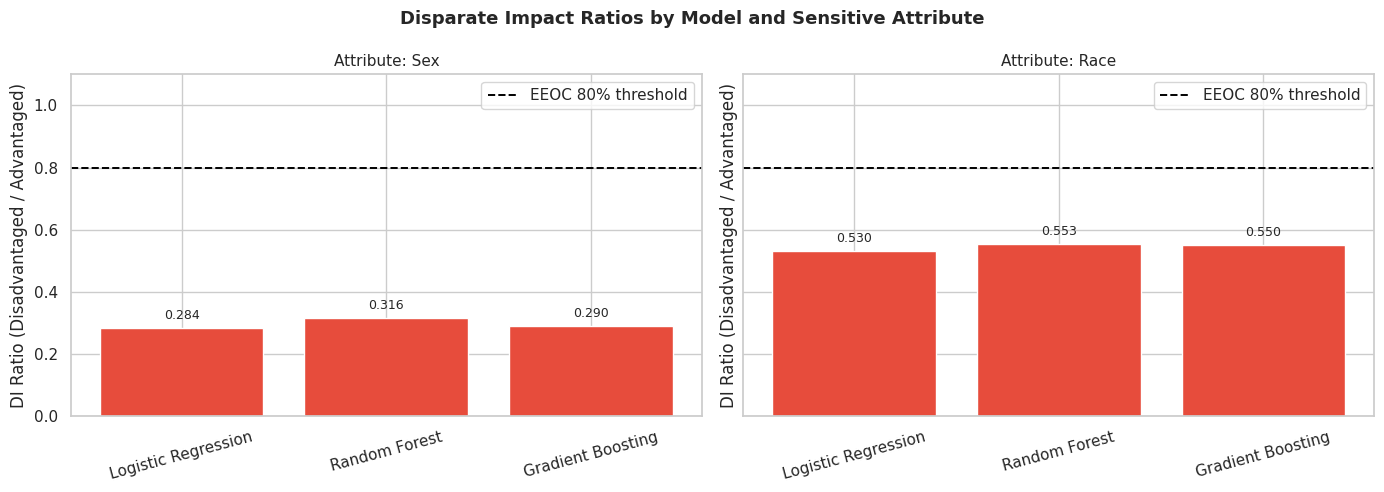

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Disparate Impact Ratios by Model and Sensitive Attribute",
             fontsize=13, fontweight="bold")

for ax, attr in zip(axes, ["Sex", "Race"]):
    subset = di_df[di_df["Attribute"] == attr]
    bars   = ax.bar(subset["Model"], subset["DI_ratio"],
                    color=["#e74c3c" if v < 0.80 else "#2ecc71"
                           for v in subset["DI_ratio"]])
    ax.axhline(0.80, color="black", linestyle="--", linewidth=1.4,
               label="EEOC 80% threshold")
    ax.set_title(f"Attribute: {attr}", fontsize=11)
    ax.set_ylabel("DI Ratio (Disadvantaged / Advantaged)")
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="x", rotation=15)
    ax.legend()

    for bar, val in zip(bars, subset["DI_ratio"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

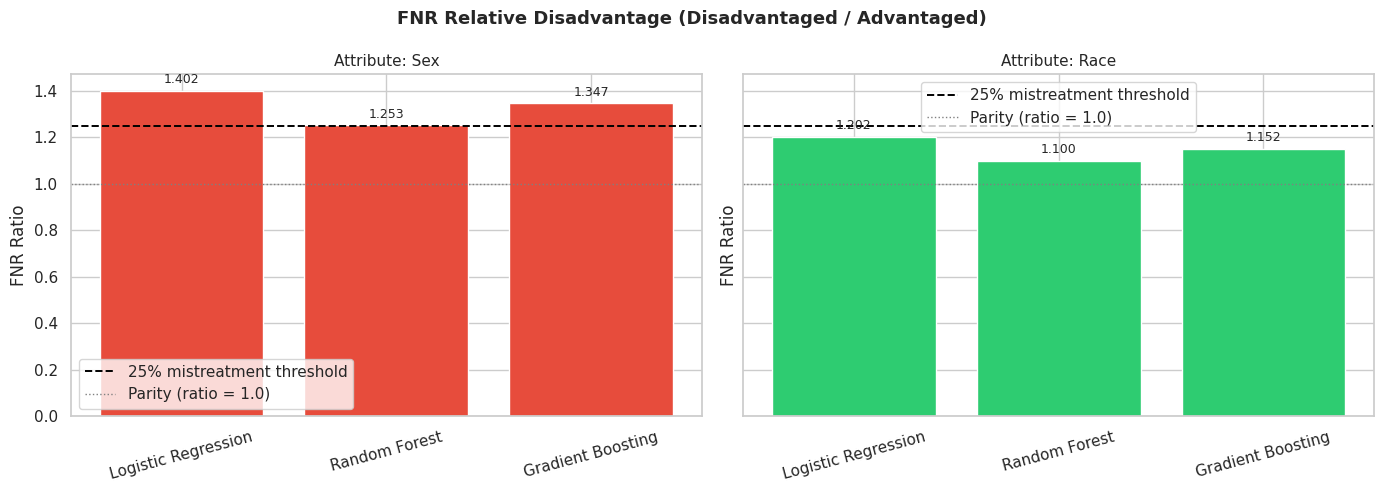

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("FNR Relative Disadvantage (Disadvantaged / Advantaged)",
             fontsize=13, fontweight="bold")

for ax, attr in zip(axes, ["Sex", "Race"]):
    subset = di_df[di_df["Attribute"] == attr]
    bars   = ax.bar(subset["Model"], subset["FNR_ratio"],
                    color=["#e74c3c" if v > 1.25 else "#2ecc71"
                           for v in subset["FNR_ratio"]])
    ax.axhline(1.25, color="black", linestyle="--", linewidth=1.4,
               label="25% mistreatment threshold")
    ax.axhline(1.00, color="gray", linestyle=":", linewidth=1,
               label="Parity (ratio = 1.0)")
    ax.set_title(f"Attribute: {attr}", fontsize=11)
    ax.set_ylabel("FNR Ratio")
    ax.tick_params(axis="x", rotation=15)
    ax.legend()

    for bar, val in zip(bars, subset["FNR_ratio"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Step 9 — Structured Bias Analysis

### Observed Systemic Bias Mechanisms

Differences in FPR, FNR, FDR, and FOR across sex and race groups may arise from:

### 1. Historical Dataset Imbalance
The Adult dataset reflects historical socioeconomic disparities, where income opportunities were unevenly distributed across sex and race. The training data encodes this history.

### 2. Proxy Variable Leakage
Features such as `occupation`, `education_num`, `marital_status`, and `relationship` may **indirectly encode** demographic inequalities — even after sensitive attributes are excluded from the feature matrix (not done here, by design).

### 3. Error Distribution Inequality
- Higher **FNR** for a subgroup → qualified individuals are disproportionately *denied* positive predictions (denied income)
- Higher **FPR** → low-income individuals in a group receive more *false* high-income predictions
- Higher **FDR / FOR** → unequal trustworthiness of positive / negative predictions for that group

### 4. Institutional Reproduction
Baseline classifiers trained on historically biased data replicate pre-existing structural inequalities unless explicit fairness interventions are introduced.

---

## Conclusion

All three baseline models exhibit **significant disparate impact** (DI < 0.80) across both sex and race attributes, consistent with the EEOC Four-Fifths Rule threshold.  
The **FNR gap** — where female and non-white individuals are disproportionately denied high-income predictions they qualify for — is the most consequential fairness violation observed.

These findings emphasise the necessity of fairness auditing before deployment in socially sensitive domains such as hiring, lending, credit scoring, or public policy.
